# Compare NetCDF Coordinates

This notebook reads two NetCDF files and checks if their latitude and longitude coordinate arrays are the same.

## 1. Import Required Libraries

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

## 2. Load NetCDF Files

Specify the paths to your two NetCDF files and load them.

In [2]:
# --- CONFIGURATION ---
dpscream_file = "scream_gpu_dpxx_RCE_dx1km.fullfield.AVERAGE.nhours_x1.2000-01-01-00000.nc"
scrip_file    = "scrip_DPSCREAM_RCE_dx1km_600x600km.nc"
target_lat    = 0.0 # Must match what you used to generate the SCRIP file
target_lon    = 0.0

# --- LOAD DATA ---
ds_dp = xr.open_dataset(dpscream_file)
ds_scrip = xr.open_dataset(scrip_file)

## 3. Extract Latitude and Longitude Coordinates

Extract the lat and lon coordinate arrays from both files.

In [3]:
# 1. Extract Arrays
# DP-SCREAM (Meters)
lat_dp_m = ds_dp['lat'].values
lon_dp_m = ds_dp['lon'].values

In [4]:
# SCRIP (Degrees)
lat_scrip_deg = ds_scrip['grid_center_lat'].values
lon_scrip_deg = ds_scrip['grid_center_lon'].values

In [5]:
# --- BACK-CALCULATION ---
# Convert SCRIP Degrees back to Meters to compare apples-to-apples
m_per_deg_lat = 111320.0
m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(target_lat))

In [6]:
lat_scrip_m = (lat_scrip_deg - target_lat) * m_per_deg_lat
lon_scrip_m = (lon_scrip_deg - target_lon) * m_per_deg_lon

In [7]:
# --- CHECK CONSISTENCY ---
# Calculate the difference
diff_lat = lat_dp_m - lat_scrip_m
diff_lon = lon_dp_m - lon_scrip_m

print(f"Max Latitude Difference: {np.max(np.abs(diff_lat)):.4f} meters")
print(f"Max Longitude Difference: {np.max(np.abs(diff_lon)):.4f} meters")

Max Latitude Difference: 300000.0132 meters
Max Longitude Difference: 300000.0000 meters


In [8]:
lon_dp_m[0:32]


array([  750.,  2250.,   750.,  2250.,  3750.,  5250.,  3750.,  5250.,
        6750.,  8250.,  6750.,  8250.,  9750., 11250.,  9750., 11250.,
       12750., 14250., 12750., 14250., 15750., 17250., 15750., 17250.,
       18750., 20250., 18750., 20250., 21750., 23250., 21750., 23250.],
      dtype=float32)

In [9]:

lat_dp_m[0:32]

array([ 750.,  750., 2250., 2250.,  750.,  750., 2250., 2250.,  750.,
        750., 2250., 2250.,  750.,  750., 2250., 2250.,  750.,  750.,
       2250., 2250.,  750.,  750., 2250., 2250.,  750.,  750., 2250.,
       2250.,  750.,  750., 2250., 2250.], dtype=float32)

(0.0, 40.0)

(0.0, 40000.0)

np.float32(599250.0)

np.float32(750.0)

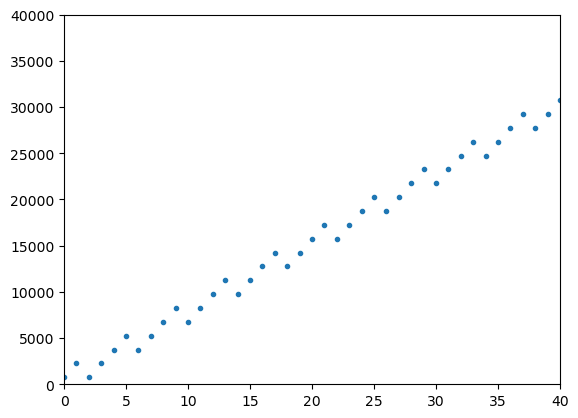

In [38]:
plt.plot(lon_dp_m,'.')
plt.xlim([0,40])
plt.ylim([0,40000])

np.max(lon_dp_m)
np.min(lon_dp_m)

(0.0, 20.0)

(0.0, 3000.0)

np.float32(5250.0)

np.float32(3750.0)

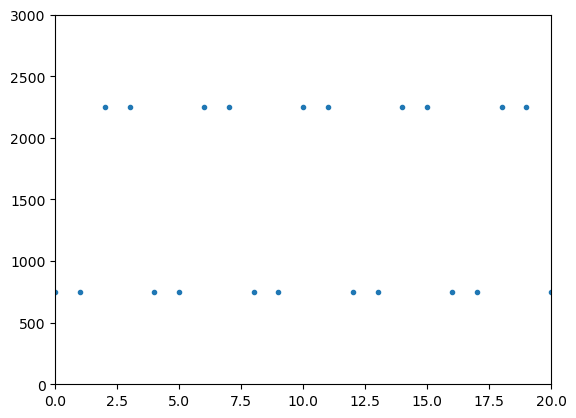

In [32]:
plt.plot(lat_dp_m,'.')
plt.xlim([0,20])
plt.ylim([0,3000])

np.max(lat_dp_m[800:1000])
np.min(lat_dp_m[800:1000])

In [10]:
array1_converted = False
array2_converted = False

if(latunits1 == 'rad') and (not array1_converted):
    print("convering lat1 and lon1 from radian to degree")
    lat1 = lat1*180.0/np.pi
    lon1 = lon1*180.0/np.pi
    array1_converted = True

if(latunits2 == 'rad') and (not array2_converted):
    print("convering lat2 and lon2 from radian to degree")
    lat2 = lat2*180.0/np.pi
    lon2 = lon2*180.0/np.pi
    array2_converted = True


NameError: name 'latunits1' is not defined

In [11]:
plt.plot(lat1,'.')



NameError: name 'lat1' is not defined

In [7]:
np.max(lat1)
np.min(lat1)

np.max(lon1)
np.min(lon1)



np.float32(599250.0)

np.float32(750.0)

np.float32(599250.0)

np.float32(750.0)

In [8]:
np.max(lat2)
np.min(lat2)

np.max(lon2)
np.min(lon2)


np.float64(2.688196191160618)

np.float64(-2.688196191160618)

np.float64(2.688196191160618)

np.float64(-2.688196191160618)

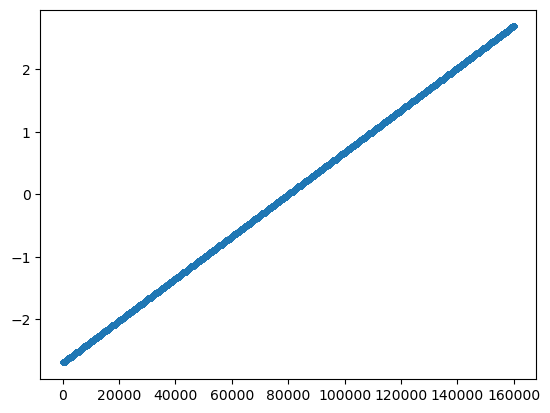

In [5]:

plt.plot(lat2,'.')


## 4. Compare Coordinate Arrays

Check if the latitude and longitude arrays are identical.

In [23]:
# Check shape compatibility
print("=== Shape Comparison ===")
if lat1 is not None and lat2 is not None:
    print(f"Latitude shapes match: {lat1.shape == lat2.shape}")
    print(f"  File 1: {lat1.shape}")
    print(f"  File 2: {lat2.shape}")
else:
    print("Could not find latitude in one or both files")

if lon1 is not None and lon2 is not None:
    print(f"\nLongitude shapes match: {lon1.shape == lon2.shape}")
    print(f"  File 1: {lon1.shape}")
    print(f"  File 2: {lon2.shape}")
else:
    print("\nCould not find longitude in one or both files")

# Check exact equality
print("\n=== Exact Equality Check ===")
if lat1 is not None and lat2 is not None and lat1.shape == lat2.shape:
    lat_equal = np.array_equal(lat1, lat2)
    print(f"Latitude arrays are identical: {lat_equal}")
    if not lat_equal:
        lat_close = np.allclose(lat1, lat2)
        print(f"  Latitude arrays are close (within tolerance): {lat_close}")
        if lat_close:
            max_diff = np.max(np.abs(lat1 - lat2))
            print(f"  Maximum difference: {max_diff}")

if lon1 is not None and lon2 is not None and lon1.shape == lon2.shape:
    lon_equal = np.array_equal(lon1, lon2)
    print(f"\nLongitude arrays are identical: {lon_equal}")
    if not lon_equal:
        lon_close = np.allclose(lon1, lon2)
        print(f"  Longitude arrays are close (within tolerance): {lon_close}")
        if lon_close:
            max_diff = np.max(np.abs(lon1 - lon2))
            print(f"  Maximum difference: {max_diff}")

=== Shape Comparison ===
Latitude shapes match: True
  File 1: (160000,)
  File 2: (160000,)

Longitude shapes match: True
  File 1: (160000,)
  File 2: (160000,)

=== Exact Equality Check ===
Latitude arrays are identical: False
  Latitude arrays are close (within tolerance): False

Longitude arrays are identical: False
  Longitude arrays are close (within tolerance): False


## 5. Visualize Differences (if any)

If there are differences, visualize them.

Text(0.5, 1.0, 'Latitude Difference (File1 - File2)')

Text(0.5, 0, 'Index')

Text(0, 0.5, 'Difference')

Text(0.5, 1.0, 'Longitude Difference (File1 - File2)')

Text(0.5, 0, 'Index')

Text(0, 0.5, 'Difference')

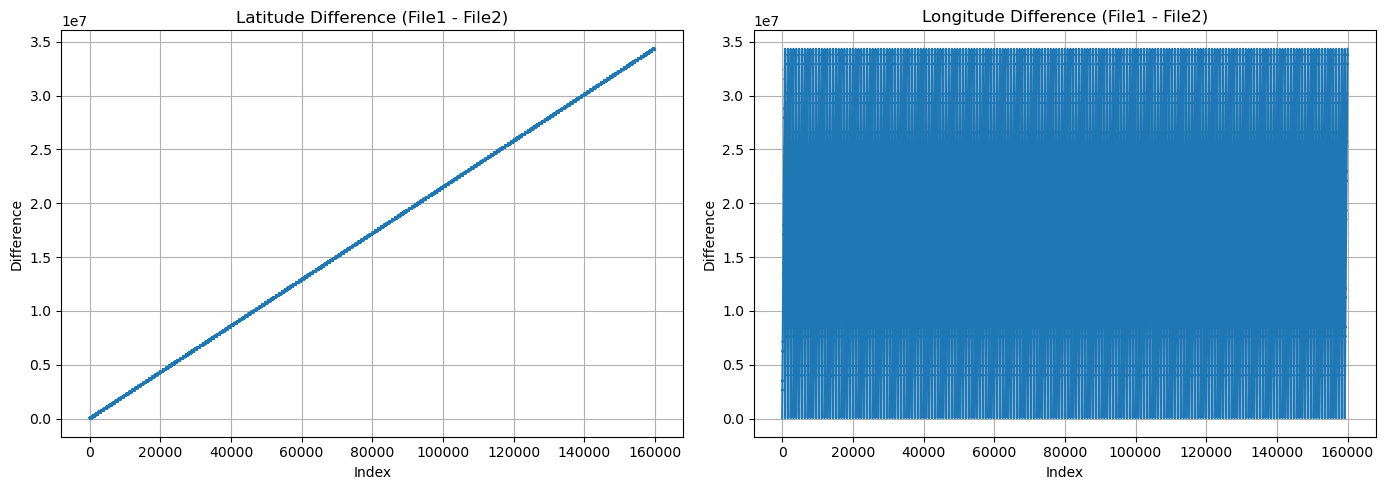

In [24]:
# Plot coordinate differences if they exist and have the same shape
if lat1 is not None and lat2 is not None and lat1.shape == lat2.shape:
    if not np.array_equal(lat1, lat2):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Latitude difference
        lat_diff = lat1 - lat2
        im1 = axes[0].plot(lat_diff.flatten() if lat_diff.ndim > 1 else lat_diff)
        axes[0].set_title('Latitude Difference (File1 - File2)')
        axes[0].set_xlabel('Index')
        axes[0].set_ylabel('Difference')
        axes[0].grid(True)
        
        # Longitude difference
        if lon1 is not None and lon2 is not None and lon1.shape == lon2.shape:
            lon_diff = lon1 - lon2
            im2 = axes[1].plot(lon_diff.flatten() if lon_diff.ndim > 1 else lon_diff)
            axes[1].set_title('Longitude Difference (File1 - File2)')
            axes[1].set_xlabel('Index')
            axes[1].set_ylabel('Difference')
            axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Coordinates are identical - no differences to visualize")
else:
    print("Cannot visualize differences - shapes don't match or coordinates not found")